In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [147]:
# Load labels
labels = pd.read_csv('data/class.tsv', sep='\t', header=None, names=['label'])
y = labels['label'].values
print('Samples:', len(y), '| ER+:', (y==1).sum(), '| ER-:', (y==0).sum())

Samples: 105 | ER+: 45 | ER-: 60


In [148]:
# Load expression matrix
expr = pd.read_csv('data/filtered.tsv.gz', sep='\t', compression='gzip')
print('Expression matrix shape:', expr.shape)
print('First 5 column names:', expr.columns[:5].tolist())

Expression matrix shape: (105, 16174)
First 5 column names: ['    1', '    2', '    6', '   12', '   13']


In [149]:
# Force pandas to accept up to 30 columns (filling empty spaces with NaN)
# to prevent the ParserError on longer rows.
genes_raw = pd.read_csv('data/columns.tsv.gz', sep='\t', compression='gzip', comment='#', header=None)

print('columns.tsv.gz shape:', genes_raw.shape)
print(genes_raw.head())

columns.tsv.gz shape: (27649, 16)
   0                  1              2                                3   \
0  ID               TYPE     ReporterID                         GeneName   
1   1  cDNA_landinglight  IMAGE:2580289                      B-actin_1/4   
2   2  cDNA_landinglight  IMAGE:2580289                      B-actin_1/8   
3   3         cDNA_clone   BC DDP 2 E12  AL122097 DKFZp434P1215(unknown)   
4   4         cDNA_clone   BC DDP 2 G12                          strange   

           4               5             6                     7           8   \
0  GeneSymbol  UniGeneCluster  UniGeneBuild               GB_LIST  EntrezGene   
1        ACTB       Hs.520640           188  AW081870,  NM_001101          60   
2        ACTB       Hs.520640           188  AW081870,  NM_001101          60   
3         NaN             NaN           NaN                   NaN         NaN   
4         NaN             NaN           NaN                   NaN         NaN   

            9         

In [150]:
genes = genes_raw.iloc[:, [0, 4]].copy()
genes.columns = ['gene_id', 'gene_name']

# 3. Clean the text
# This strips away any invisible spaces, tabs, or quotes that would break the search
genes['gene_id'] = genes['gene_id'].astype(str).str.strip().str.replace('"', '').str.replace("'", "")
genes['gene_name'] = genes['gene_name'].astype(str).str.strip().str.replace('"', '').str.replace("'", "")

print("Cleaned Genes Dataframe:")
print(genes.head())

Cleaned Genes Dataframe:
  gene_id   gene_name
0      ID  GeneSymbol
1       1        ACTB
2       2        ACTB
3       3         nan
4       4         nan


In [151]:
# Extract expression for a given gene name
# Convert all expression column names to strings and strip hidden characters
expr.columns = expr.columns.astype(str).str.strip().str.replace('"', '').str.replace("'", "")

# Let's peek at what the columns and our gids actually look like to be absolutely sure
print("First 5 expr columns:", expr.columns[:5].tolist())

# Extract expression for a given gene name
def get_expr(gene_name):
    # Get the matching IDs for the gene
    gids = genes.loc[genes['gene_name'] == gene_name, 'gene_id'].values
    gids = [str(g).strip() for g in gids] # Force to clean string
    
    # Find which of those IDs are actually in the expression dataframe
    cols = [c for c in gids if c in expr.columns]
    
    if not cols:
        raise ValueError(f'{gene_name} not found in expression data. IDs tried: {gids}. First 5 expr columns are: {expr.columns[:5].tolist()}')
        
    print(f'{gene_name}: using columns {cols}')
    return expr[cols].mean(axis=1).values

# Now try fetching the data!
xbp1  = get_expr('XBP1')
gata3 = get_expr('GATA3')

print('XBP1  - ER+ mean:', xbp1[y==1].mean().round(3), '| ER- mean:', xbp1[y==0].mean().round(3))
print('GATA3 - ER+ mean:', gata3[y==1].mean().round(3), '| ER- mean:', gata3[y==0].mean().round(3))

First 5 expr columns: ['1', '2', '6', '12', '13']
XBP1: using columns ['4404']
GATA3: using columns ['4359']
XBP1  - ER+ mean: 2.121 | ER- mean: 0.561
GATA3 - ER+ mean: 2.203 | ER- mean: 0.288


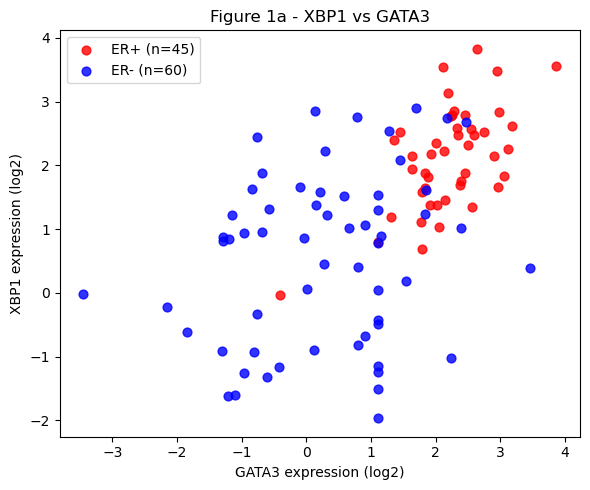

In [152]:
# Figure 1a: XBP1 vs GATA3 scatter coloured by ER status
plt.figure(figsize=(6, 5))
plt.scatter(gata3[y==1], xbp1[y==1], c='red',  s=40, alpha=0.8, label='ER+ (n=%d)' % (y==1).sum())
plt.scatter(gata3[y==0], xbp1[y==0], c='blue', s=40, alpha=0.8, label='ER- (n=%d)' % (y==0).sum())
plt.xlabel('GATA3 expression (log2)')
plt.ylabel('XBP1 expression (log2)')
plt.title('Figure 1a - XBP1 vs GATA3')
plt.legend()
plt.tight_layout()
plt.savefig('figure1a.png', dpi=150)
plt.show()

In [153]:
# PCA on the 2D matrix (XBP1, GATA3)
X = np.column_stack([xbp1, gata3])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pc_scores = pca.fit_transform(X_scaled)
pc1 = pc_scores[:, 0]

print(f'PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC1 loadings - XBP1: {pca.components_[0,0]:.3f}, GATA3: {pca.components_[0,1]:.3f}')

PC1 variance explained: 77.9%
PC1 loadings - XBP1: 0.707, GATA3: 0.707


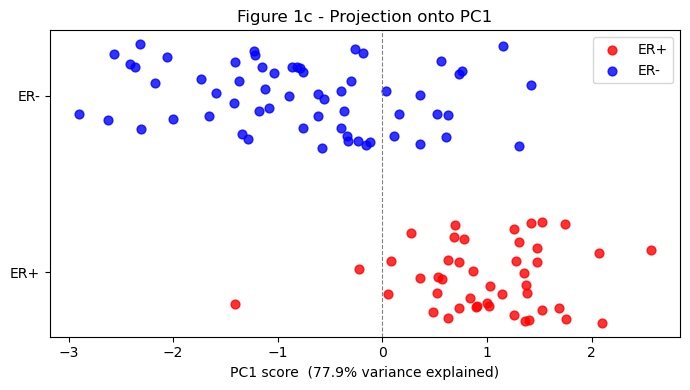

In [154]:
# Figure 1c: PC1 projection strip plot
np.random.seed(42)

plt.figure(figsize=(7, 4))
plt.scatter(pc1[y==1], np.random.uniform(0.7, 1.3, (y==1).sum()), c='red',  s=40, alpha=0.8, label='ER+')
plt.scatter(pc1[y==0], np.random.uniform(1.7, 2.3, (y==0).sum()), c='blue', s=40, alpha=0.8, label='ER-')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.yticks([1, 2], ['ER+', 'ER-'])
plt.xlabel(f'PC1 score  ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
plt.title('Figure 1c - Projection onto PC1')
plt.legend()
plt.tight_layout()
plt.savefig('figure1c.png', dpi=150)
plt.show()